In [ ]:
#Install & Import Libraries
!pip install mysql-connector-python

import pandas as pd
import numpy as np
import mysql.connector
import re
from sqlalchemy import create_engine
# import matplotlib.pyplot as plt
# import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 54.3 MB/s eta 0:00:00


In [ ]:
#Connect to the Database
conn = mysql.connector.connect(
    host     = "18.136.157.135",
    user     = "dm_team8",
    password = "DM!$!Team!82@04!23&",
    database = "project_job_market_analysis"
)
print("Connected successfully!")

Connected successfully!


In [ ]:
# SQLAlchemy Engine
from sqlalchemy import create_engine
db_connection_str = "mysql+mysqlconnector://dm_team8:DM!$!Team!82@04!23&@18.136.157.135/project_job_market_analysis"
engine = create_engine(db_connection_str)

print("SQLAlchemy engine created successfully!")

SQLAlchemy engine created successfully!


In [ ]:
#Load and Explore the Data
query = 'SELECT * FROM Market'
df = pd.read_sql(query, conn)
print("Initial Shape:", df.shape)
display(df.head())

/tmp/ipykernel_6692/1888060085.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Initial Shape: (742, 42)


,ID,Job_Title,Salary_Estimate,FIELD4,Rating,Company_Name,Location,Headquarters,Size,Founded,...,tensor,hadoop,tableau,bi,flink,mongo,google_an,job_title_sim,seniority_by_title,Degree
0,0,Data Scientist,$53K-$91K (Glassdoor est.),None,3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 - 1000,1973,...,0,0,1,1,0,0,0,data scientist,na,M
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),None,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+,1984,...,0,0,0,0,0,0,0,data scientist,na,M
2,2,Data Scientist,$80K-$90K (Glassdoor est.),None,4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 - 1000,2010,...,0,0,0,0,0,0,0,data scientist,na,M
3,3,Data Scientist,$56K-$97K (Glassdoor est.),None,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 - 5000,1965,...,0,0,0,0,0,0,0,data scientist,na,na
4,4,Data Scientist,$86K-$143K (Glassdoor est.),None,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 - 200,1998,...,0,0,0,0,0,0,0,data scientist,na,na


RAW DATA
(Download)

In [ ]:
# # Reload the raw data from the database to ensure it's uncleaned
# query_raw = 'SELECT * FROM Market'
# df_raw = pd.read_sql(query_raw, conn)

# df_raw.to_csv('job_market_raw_original.csv', index=False)
# print('Truly raw dataset saved as job_market_raw_original.csv')

# from google.colab import files
# files.download('job_market_raw_original.csv')

In [ ]:
# Show all available tables
cursor = conn.cursor()
cursor.execute('SHOW TABLES')
for table in cursor:
    print(table)

('Market',)


In [ ]:
# Shape of the dataset (rows, columns)
print('Shape:', df.shape)

Shape: (742, 42)


In [ ]:
# Column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 42 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  742 non-null    int64  
 1   Job_Title           742 non-null    object 
 2   Salary_Estimate     742 non-null    object 
 3   FIELD4              0 non-null      object 
 4   Rating              742 non-null    float64
 5   Company_Name        742 non-null    object 
 6   Location            742 non-null    object 
 7   Headquarters        742 non-null    object 
 8   Size                742 non-null    object 
 9   Founded             742 non-null    int64  
 10  Type_of_ownership   742 non-null    object 
 11  Industry            742 non-null    object 
 12  Sector              742 non-null    object 
 13  Revenue             742 non-null    object 
 14  Competitors         742 non-null    object 
 15  Hourly              742 non-null    int64  
 16  Employer

In [ ]:
# All column names
print(df.columns.tolist())

['ID', 'Job_Title', 'Salary_Estimate', 'FIELD4', 'Rating', 'Company_Name', 'Location', 'Headquarters', 'Size', 'Founded', 'Type_of_ownership', 'Industry', 'Sector', 'Revenue', 'Competitors', 'Hourly', 'Employer_provided', 'Lower_Salary', 'Upper_Salary', 'Avg_SalaryK', 'company_txt', 'Job_Location', 'Age', 'Python', 'spark', 'aws', 'excel', 'sql_', 'sas', 'keras', 'pytorch', 'scikit', 'tensor', 'hadoop', 'tableau', 'bi', 'flink', 'mongo', 'google_an', 'job_title_sim', 'seniority_by_title', 'Degree']


### Data cleaning & Handling Missing Values (represented by -1 or '-1')

In [ ]:
import numpy as np

# Drop the 'FIELD4' column as it contains all null values
df = df.drop(columns=['FIELD4'])
print("Dropped 'FIELD4' column.")

Dropped 'FIELD4' column.


In [ ]:
# Verify the changes
# print('\nDataFrame Info after handling missing values:')
# df.info()
# print('\nFirst 5 rows after handling missing values:')
# display(df.head())

In [ ]:
# Identify columns that might contain '-1' or -1

# Numerical columns to check for -1
num_cols_to_check = ['Rating', 'Founded', 'Age']
for col in num_cols_to_check:
    if col in df.columns and (df[col] == -1).any():
        df[col] = df[col].replace(-1, np.nan)
        print(f"Replaced -1 with NaN in numerical column '{col}'.")

# Categorical/Object columns to check for '-1' string
obj_cols_to_check = ['Size', 'Revenue', 'Competitors', 'Headquarters', 'Type_of_ownership', 'Industry', 'Sector', 'Job_Title', 'Location', 'Salary_Estimate', 'company_txt', 'Job_Location', 'job_title_sim', 'seniority_by_title', 'Degree']
for col in obj_cols_to_check:
    if col in df.columns and (df[col] == '-1').any():
        df[col] = df[col].replace('-1', np.nan)
        print(f"Replaced '-1' with NaN in object column '{col}'.")

Replaced -1 with NaN in numerical column 'Rating'.
Replaced -1 with NaN in numerical column 'Founded'.
Replaced -1 with NaN in numerical column 'Age'.
Replaced '-1' with NaN in object column 'Competitors'.
Replaced '-1' with NaN in object column 'Headquarters'.
Replaced '-1' with NaN in object column 'Industry'.
Replaced '-1' with NaN in object column 'Sector'.


In [ ]:
# Impute missing values

# Impute numerical columns with their median
for col in num_cols_to_check:
    if col in df.columns and df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Imputed NaN in numerical column '{col}' with median: {median_val}.")

# Impute categorical columns with 'Unknown'
for col in obj_cols_to_check:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna('Unknown')
        print(f"Imputed NaN in object column '{col}' with 'Unknown'.")

Imputed NaN in numerical column 'Rating' with median: 3.7.
Imputed NaN in numerical column 'Founded' with median: 1992.0.
Imputed NaN in numerical column 'Age' with median: 29.0.
Imputed NaN in object column 'Competitors' with 'Unknown'.
Imputed NaN in object column 'Headquarters' with 'Unknown'.
Imputed NaN in object column 'Industry' with 'Unknown'.
Imputed NaN in object column 'Sector' with 'Unknown'.


In [ ]:
#### Cleaning Column Names
def clean_column_name(col_name):
    # Convert to lowercase
    col_name = col_name.lower()
    # Replace spaces with underscores
    col_name = col_name.replace(' ', '_')
    # Remove special characters (keep only alphanumeric and underscores)
    col_name = re.sub(r'[^a-z0-9_]', '', col_name)
    return col_name

df.columns = [clean_column_name(col) for col in df.columns]

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['id', 'job_title', 'salary_estimate', 'rating', 'company_name', 'location', 'headquarters', 'size', 'founded', 'type_of_ownership', 'industry', 'sector', 'revenue', 'competitors', 'hourly', 'employer_provided', 'lower_salary', 'upper_salary', 'avg_salaryk', 'company_txt', 'job_location', 'age', 'python', 'spark', 'aws', 'excel', 'sql_', 'sas', 'keras', 'pytorch', 'scikit', 'tensor', 'hadoop', 'tableau', 'bi', 'flink', 'mongo', 'google_an', 'job_title_sim', 'seniority_by_title', 'degree']


In [ ]:
#Fix Company Name
df['company_name'] = df['company_name'].astype(str).apply(lambda x: x.split('\n')[0])

In [ ]:
# Verify the changes by displaying info and head
print('\nDataFrame Info after cleaning column names:')
df.info()
print('\nFirst 5 rows after cleaning column names:')
display(df.head())


DataFrame Info after cleaning column names:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 41 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  742 non-null    int64  
 1   job_title           742 non-null    object 
 2   salary_estimate     742 non-null    object 
 3   rating              742 non-null    float64
 4   company_name        742 non-null    object 
 5   location            742 non-null    object 
 6   headquarters        742 non-null    object 
 7   size                742 non-null    object 
 8   founded             742 non-null    float64
 9   type_of_ownership   742 non-null    object 
 10  industry            742 non-null    object 
 11  sector              742 non-null    object 
 12  revenue             742 non-null    object 
 13  competitors         742 non-null    object 
 14  hourly              742 non-null    int64  
 15  employer_pro

,id,job_title,salary_estimate,rating,company_name,location,headquarters,size,founded,type_of_ownership,...,tensor,hadoop,tableau,bi,flink,mongo,google_an,job_title_sim,seniority_by_title,degree
0,0,Data Scientist,$53K-$91K (Glassdoor est.),3.8,Tecolote Research,"Albuquerque, NM","Goleta, CA",501 - 1000,1973.0,Company - Private,...,0,0,1,1,0,0,0,data scientist,na,M
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),3.4,University of Maryland Medical System,"Linthicum, MD","Baltimore, MD",10000+,1984.0,Other Organization,...,0,0,0,0,0,0,0,data scientist,na,M
2,2,Data Scientist,$80K-$90K (Glassdoor est.),4.8,KnowBe4,"Clearwater, FL","Clearwater, FL",501 - 1000,2010.0,Company - Private,...,0,0,0,0,0,0,0,data scientist,na,M
3,3,Data Scientist,$56K-$97K (Glassdoor est.),3.8,PNNL,"Richland, WA","Richland, WA",1001 - 5000,1965.0,Government,...,0,0,0,0,0,0,0,data scientist,na,na
4,4,Data Scientist,$86K-$143K (Glassdoor est.),2.9,Affinity Solutions,"New York, NY","New York, NY",51 - 200,1998.0,Company - Private,...,0,0,0,0,0,0,0,data scientist,na,na


In [ ]:
# Check columns first
print("Before drop:", df.columns.tolist())

# Drop the column PROPERLY
df = df.drop(columns=['company_txt'], errors='ignore')

# Verify it's removed
print("After drop:", df.columns.tolist())

Before drop: ['id', 'job_title', 'salary_estimate', 'rating', 'company_name', 'location', 'headquarters', 'size', 'founded', 'type_of_ownership', 'industry', 'sector', 'revenue', 'competitors', 'hourly', 'employer_provided', 'lower_salary', 'upper_salary', 'avg_salaryk', 'company_txt', 'job_location', 'age', 'python', 'spark', 'aws', 'excel', 'sql_', 'sas', 'keras', 'pytorch', 'scikit', 'tensor', 'hadoop', 'tableau', 'bi', 'flink', 'mongo', 'google_an', 'job_title_sim', 'seniority_by_title', 'degree']
After drop: ['id', 'job_title', 'salary_estimate', 'rating', 'company_name', 'location', 'headquarters', 'size', 'founded', 'type_of_ownership', 'industry', 'sector', 'revenue', 'competitors', 'hourly', 'employer_provided', 'lower_salary', 'upper_salary', 'avg_salaryk', 'job_location', 'age', 'python', 'spark', 'aws', 'excel', 'sql_', 'sas', 'keras', 'pytorch', 'scikit', 'tensor', 'hadoop', 'tableau', 'bi', 'flink', 'mongo', 'google_an', 'job_title_sim', 'seniority_by_title', 'degree']


In [ ]:
location_split = df["location"].str.split(",", n=1, expand=True)
df["City"] = location_split[0].str.strip()
df["State"] = location_split[1].str.strip()

In [ ]:
df["company_name"] = df["company_name"].replace("<intent>", "Unknown")

In [ ]:
display(df.head(30))

,id,job_title,salary_estimate,rating,company_name,location,headquarters,size,founded,type_of_ownership,...,tableau,bi,flink,mongo,google_an,job_title_sim,seniority_by_title,degree,City,State
0,0,Data Scientist,$53K-$91K (Glassdoor est.),3.8,Tecolote Research,"Albuquerque, NM","Goleta, CA",501 - 1000,1973.0,Company - Private,...,1,1,0,0,0,data scientist,na,M,Albuquerque,NM
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),3.4,University of Maryland Medical System,"Linthicum, MD","Baltimore, MD",10000+,1984.0,Other Organization,...,0,0,0,0,0,data scientist,na,M,Linthicum,MD
2,2,Data Scientist,$80K-$90K (Glassdoor est.),4.8,KnowBe4,"Clearwater, FL","Clearwater, FL",501 - 1000,2010.0,Company - Private,...,0,0,0,0,0,data scientist,na,M,Clearwater,FL
3,3,Data Scientist,$56K-$97K (Glassdoor est.),3.8,PNNL,"Richland, WA","Richland, WA",1001 - 5000,1965.0,Government,...,0,0,0,0,0,data scientist,na,na,Richland,WA
4,4,Data Scientist,$86K-$143K (Glassdoor est.),2.9,Affinity Solutions,"New York, NY","New York, NY",51 - 200,1998.0,Company - Private,...,0,0,0,0,0,data scientist,na,na,New York,NY
5,5,Data Scientist,$71K-$119K (Glassdoor est.),3.4,CyrusOne,"Dallas, TX","Dallas, TX",201 - 500,2000.0,Company - Public,...,0,1,0,1,0,data scientist,na,na,Dallas,TX
6,6,Data Scientist,$54K-$93K (Glassdoor est.),4.1,ClearOne Advantage,"Baltimore, MD","Baltimore, MD",501 - 1000,2008.0,Company - Private,...,0,0,0,0,0,data scientist,na,na,Baltimore,MD
7,7,Data Scientist,$86K-$142K (Glassdoor est.),3.8,Logic20/20,"San Jose, CA","Seattle, WA",201 - 500,2005.0,Company - Private,...,0,0,0,0,0,data scientist,na,M,San Jose,CA
8,8,Research Scientist,$38K-$84K (Glassdoor est.),3.3,Rochester Regional Health,"Rochester, NY","Rochester, NY",10000+,2014.0,Hospital,...,0,0,0,0,0,other scientist,na,P,Rochester,NY
9,9,Data Scientist,$120K-$160K (Glassdoor est.),4.6,Unknown,"New York, NY","New York, NY",51 - 200,2009.0,Company - Private,...,0,0,0,0,0,data scientist,na,na,New York,NY


In [ ]:
df["founded"].dtype

dtype('float64')

In [ ]:
df["founded"] = df["founded"].astype("Int64")

In [ ]:
df["founded"].dtype

Int64Dtype()

In [ ]:
#cleans and standardizes text columns so that all values look consistent.
text_columns = ['job_title', 'company_name', 'headquarters', 'size', 'type_of_ownership', 'industry', 'sector', 'job_title_sim', 'seniority_by_title', 'degree', 'City', 'State']

for col in text_columns:
    if col in df.columns:
        df[col] = df[col].astype(str).apply(lambda x: x.strip().title())

print("Text columns standardized.")
display(df[text_columns].head())

Text columns standardized.


,job_title,company_name,headquarters,size,type_of_ownership,industry,sector,job_title_sim,seniority_by_title,degree,City,State
0,Data Scientist,Tecolote Research,"Goleta, Ca",501 - 1000,Company - Private,Aerospace & Defense,Aerospace & Defense,Data Scientist,Na,M,Albuquerque,Nm
1,Healthcare Data Scientist,University Of Maryland Medical System,"Baltimore, Md",10000+,Other Organization,Health Care Services & Hospitals,Health Care,Data Scientist,Na,M,Linthicum,Md
2,Data Scientist,Knowbe4,"Clearwater, Fl",501 - 1000,Company - Private,Security Services,Business Services,Data Scientist,Na,M,Clearwater,Fl
3,Data Scientist,Pnnl,"Richland, Wa",1001 - 5000,Government,Energy,"Oil, Gas, Energy & Utilities",Data Scientist,Na,Na,Richland,Wa
4,Data Scientist,Affinity Solutions,"New York, Ny",51 - 200,Company - Private,Advertising & Marketing,Business Services,Data Scientist,Na,Na,New York,Ny


In [ ]:
#Replace "Na" with a meaningful category
df['job_title_sim'] = df['job_title_sim'].replace(['na', 'Na'], np.nan)
df['job_title_sim'] = df['job_title_sim'].fillna(df['job_title'])

In [ ]:
#replacing Na
df['seniority_by_title'] = df['seniority_by_title'].replace('Na', 'Other')

In [ ]:
df['degree'] = df['degree'].replace(['na', 'Na', 'NA', 'nA'], 'Unknown')

#### Step 2: Clean and Convert 'Revenue' Column


In [ ]:
#Step 2: Clean and Convert 'Revenue' Column
def parse_revenue(revenue_str):
    if pd.isna(revenue_str) or revenue_str == 'Unknown' or revenue_str == 'Company N/A':
        return np.nan

    revenue_str = revenue_str.lower().replace('(usd)', '').replace('$', '').replace(' ', '').replace('million', '000000').replace('billion', '000000000').strip()

    if 'lessthan' in revenue_str:
        return 0.5 * 1000000 # Assume 0.5 million for '<$1 million'
    elif 'morethan' in revenue_str:
        # Extract numerical part, multiply by 1 billion, then add a buffer (e.g., 50%)
        num_part = float(re.findall(r'\d+', revenue_str)[0])
        return num_part * 1000000000 * 1.5 # Assume 1.5 times the stated value for '>X billion'
    elif '-' in revenue_str:
        try:
            low, high = map(float, revenue_str.split('-'))
            return (low + high) / 2
        except ValueError:
            return np.nan
    else:
        try:
            return float(revenue_str)
        except ValueError:
            return np.nan

df['estimated_revenue'] = df['revenue'].apply(parse_revenue)

# Impute NaNs in estimated_revenue with the median
median_revenue = df['estimated_revenue'].median()
df['estimated_revenue'] = df['estimated_revenue'].fillna(median_revenue)

print("Cleaned 'Revenue' column to 'estimated_revenue'.")
display(df[['revenue', 'estimated_revenue']].head())

Cleaned 'Revenue' column to 'estimated_revenue'.


,revenue,estimated_revenue
0,$50 to $100 million (USD),500000.0
1,$2 to $5 billion (USD),500000.0
2,$100 to $500 million (USD),500000.0
3,$500 million to $1 billion (USD),500000.0
4,Unknown / Non-Applicable,500000.0


In [ ]:
print(df.columns)

Index(['id', 'job_title', 'salary_estimate', 'rating', 'company_name',
       'location', 'headquarters', 'size', 'founded', 'type_of_ownership',
       'industry', 'sector', 'revenue', 'competitors', 'hourly',
       'employer_provided', 'lower_salary', 'upper_salary', 'avg_salaryk',
       'job_location', 'age', 'python', 'spark', 'aws', 'excel', 'sql_', 'sas',
       'keras', 'pytorch', 'scikit', 'tensor', 'hadoop', 'tableau', 'bi',
       'flink', 'mongo', 'google_an', 'job_title_sim', 'seniority_by_title',
       'degree', 'City', 'State', 'estimated_revenue'],
      dtype='object')


In [ ]:
display(df['avg_salaryk'].head())

,avg_salaryk
0,72.0
1,87.5
2,85.0
3,76.5
4,114.5


In [ ]:
# ================================
# FINAL SALARY CLEANING (PUT HERE)
# ================================

# Convert from K → actual dollars
df['lower_salary'] = df['lower_salary'] * 1000
df['upper_salary'] = df['upper_salary'] * 1000
df['avg_salary'] = df['avg_salaryk'] * 1000

# Drop unnecessary columns
df = df.drop(columns=['salary_estimate', 'avg_salaryk'], errors='ignore')

# Optional: remove invalid rows
df = df[df['avg_salary'].notna()]
df = df[df['avg_salary'] > 0]

print("Salary cleaned successfully!")
display(df[['lower_salary', 'upper_salary', 'avg_salary']].head())

Salary cleaned successfully!


,lower_salary,upper_salary,avg_salary
0,53000,91000,72000.0
1,63000,112000,87500.0
2,80000,90000,85000.0
3,56000,97000,76500.0
4,86000,143000,114500.0


In [ ]:
display(df.head())

,id,job_title,rating,company_name,location,headquarters,size,founded,type_of_ownership,industry,...,flink,mongo,google_an,job_title_sim,seniority_by_title,degree,City,State,estimated_revenue,avg_salary
0,0,Data Scientist,3.8,Tecolote Research,"Albuquerque, NM","Goleta, Ca",501 - 1000,1973,Company - Private,Aerospace & Defense,...,0,0,0,Data Scientist,Other,M,Albuquerque,Nm,500000.0,72000.0
1,1,Healthcare Data Scientist,3.4,University Of Maryland Medical System,"Linthicum, MD","Baltimore, Md",10000+,1984,Other Organization,Health Care Services & Hospitals,...,0,0,0,Data Scientist,Other,M,Linthicum,Md,500000.0,87500.0
2,2,Data Scientist,4.8,Knowbe4,"Clearwater, FL","Clearwater, Fl",501 - 1000,2010,Company - Private,Security Services,...,0,0,0,Data Scientist,Other,M,Clearwater,Fl,500000.0,85000.0
3,3,Data Scientist,3.8,Pnnl,"Richland, WA","Richland, Wa",1001 - 5000,1965,Government,Energy,...,0,0,0,Data Scientist,Other,Unknown,Richland,Wa,500000.0,76500.0
4,4,Data Scientist,2.9,Affinity Solutions,"New York, NY","New York, Ny",51 - 200,1998,Company - Private,Advertising & Marketing,...,0,0,0,Data Scientist,Other,Unknown,New York,Ny,500000.0,114500.0


State
Ca    151
Ma    103
Ny     72
Va     41
Il     40
Md     35
Pa     33
Tx     28
Wa     21
Nc     21
Name: count, dtype: int64


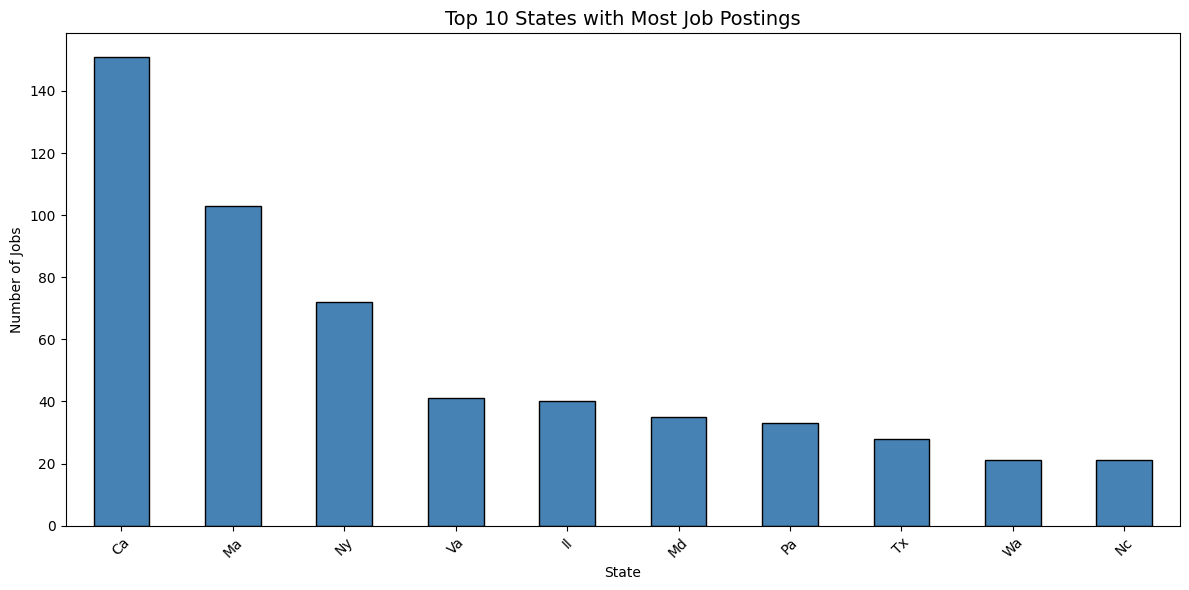

In [ ]:
import matplotlib.pyplot as plt

#Task 1 States with the Most Number of Jobs
state_jobs = df['State'].value_counts()
print(state_jobs.head(10))

plt.figure(figsize=(12, 6))
state_jobs.head(10).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 10 States with Most Job Postings', fontsize=14)
plt.xlabel('State')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#Task 2 Average Minimum and Maximum Salaries in different States
salary_state = df.groupby('State')[['lower_salary', 'upper_salary']].mean().round(2)
print(salary_state.sort_values('upper_salary', ascending=False).head(10))

                 lower_salary  upper_salary
State                                      
Ca                   92496.69     154741.72
Il                   88350.00     144975.00
Ma                   78689.32     136300.97
Los Angeles, Ca      82000.00     133000.00
Nj                   76823.53     132294.12
Dc                   88636.36     131727.27
Nc                   69047.62     127857.14
Ky                   66333.33     127666.67
Md                   68314.29     126400.00
Ri                   74000.00     126000.00


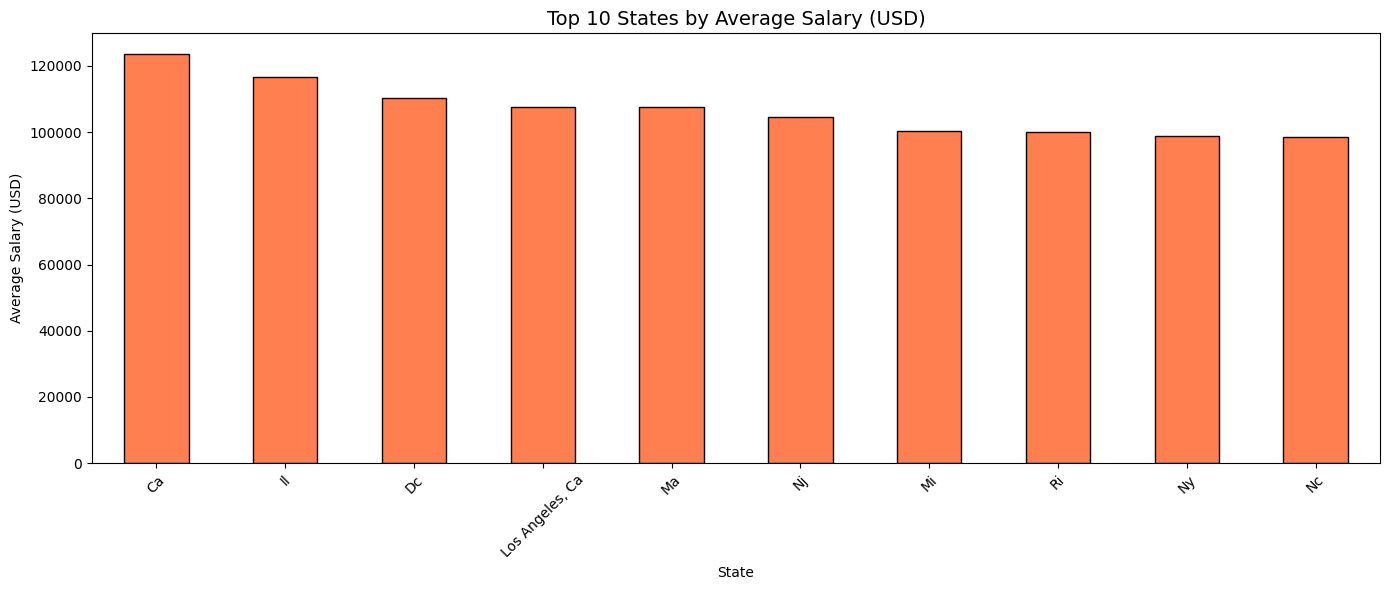

In [ ]:
#Task3 Average Salary in different State
avg_salary_state = df.groupby('State')['avg_salary'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
avg_salary_state.head(10).plot(kind='bar', color='coral', edgecolor='black')
plt.title('Top 10 States by Average Salary (USD)', fontsize=14)
plt.xlabel('State')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

industry
Biotech & Pharmaceuticals           112
Insurance Carriers                   63
Computer Hardware & Software         59
It Services                          50
Health Care Services & Hospitals     49
Name: count, dtype: int64


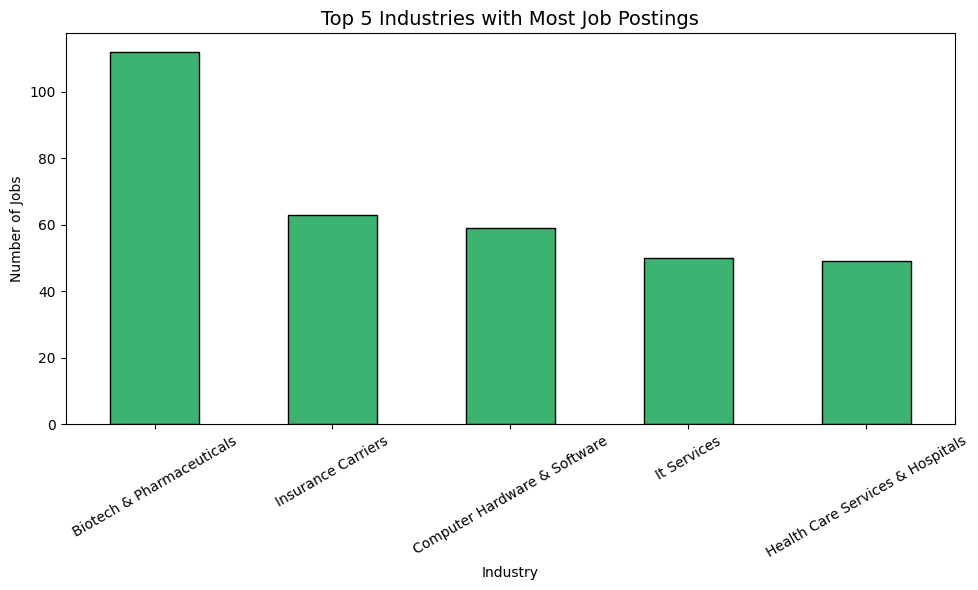

In [ ]:
###Task4 Top 5 Industries with Maximum Data Science related Job Postings
top_industries = df['industry'].value_counts().head(5)
print(top_industries)

plt.figure(figsize=(10, 6))
top_industries.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Top 5 Industries with Most Job Postings', fontsize=14)
plt.xlabel('Industry')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

company_name
Massmutual                        14
Takeda Pharmaceuticals            14
Reynolds American                 14
Software Engineering Institute    11
Pnnl                              10
Liberty Mutual Insurance          10
Astrazeneca                        9
Mitre                              8
Novartis                           7
Pfizer                             7
Name: count, dtype: int64


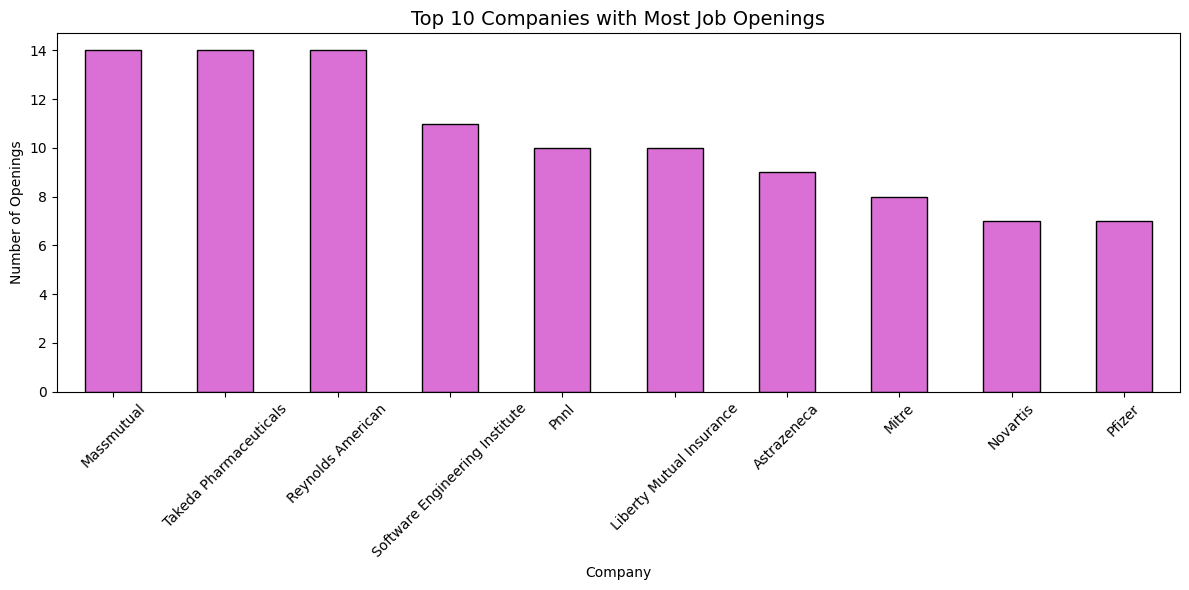

In [ ]:
### Task 5 — Companies with Maximum Number of Job Openings
top_companies = df['company_name'].value_counts().head(10)
print(top_companies)

plt.figure(figsize=(12, 6))
top_companies.plot(kind='bar', color='orchid', edgecolor='black')
plt.title('Top 10 Companies with Most Job Openings', fontsize=14)
plt.xlabel('Company')
plt.ylabel('Number of Openings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
### Task 6 — Job Titles with the Most Number of Jobs
top_jobs = df['job_title'].value_counts().head(10)
print(top_jobs)

job_title
Data Scientist               131
Data Engineer                 53
Senior Data Scientist         34
Data Analyst                  15
Senior Data Engineer          14
Senior Data Analyst           12
Lead Data Scientist            8
Sr. Data Engineer              6
Marketing Data Analyst         6
Machine Learning Engineer      5
Name: count, dtype: int64


job_title
Director Ii, Data Science - Grm Actuarial                 254000.0
Principal Machine Learning Scientist                      232500.0
Principal Data Scientist With Over 10 Years Experience    225000.0
Lead Data Engineer                                        205000.0
Director Ii, Data Science - Grs Predictive Analytics      194500.0
Staff Machine Learning Engineer                           181000.0
Director, Data Science                                    179500.0
Principal Data Scientist                                  176300.0
Sr. Scientist Ii                                          174000.0
Senior Quantitative Analyst                               173000.0
Name: avg_salary, dtype: float64


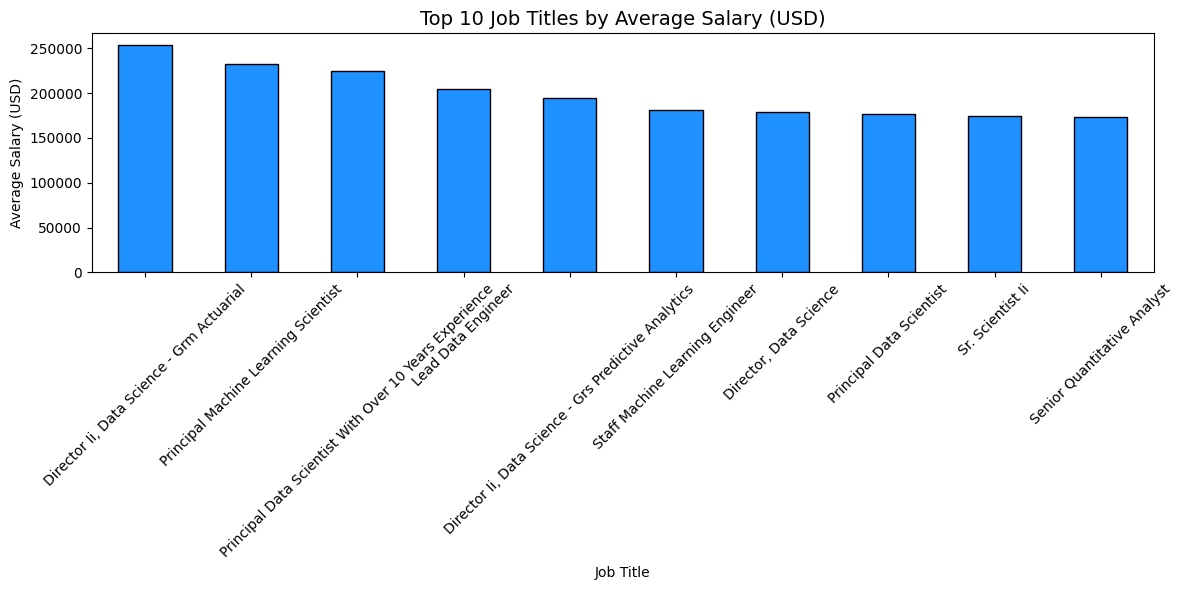

In [ ]:
### Task 7 — Salary of Job Titles with Most Jobs
salary_by_job = df.groupby('job_title')['avg_salary'].mean().sort_values(ascending=False)
print(salary_by_job.head(10))

plt.figure(figsize=(12, 6))
salary_by_job.head(10).plot(kind='bar', color='dodgerblue', edgecolor='black')
plt.title('Top 10 Job Titles by Average Salary (USD)', fontsize=14)
plt.xlabel('Job Title')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

                                                    python  sql_  excel  \
job_title_sim                                                             
Analyst                                               0.31  0.74   0.76   
Data Analitics                                        0.62  0.50   0.50   
Data Engineer                                         0.65  0.73   0.45   
Data Management Specialist                            0.00  1.00   1.00   
Data Modeler                                          0.40  0.80   0.80   
Data Operations Lead                                  1.00  1.00   1.00   
Data Scientist                                        0.77  0.56   0.50   
Data Scientist Project Manager                        0.25  0.69   0.69   
Director                                              0.00  0.00   0.40   
Enterprise Architect, Data                            1.00  1.00   1.00   
Machine Learning Engineer                             0.82  0.59   0.32   
Other Scientist          

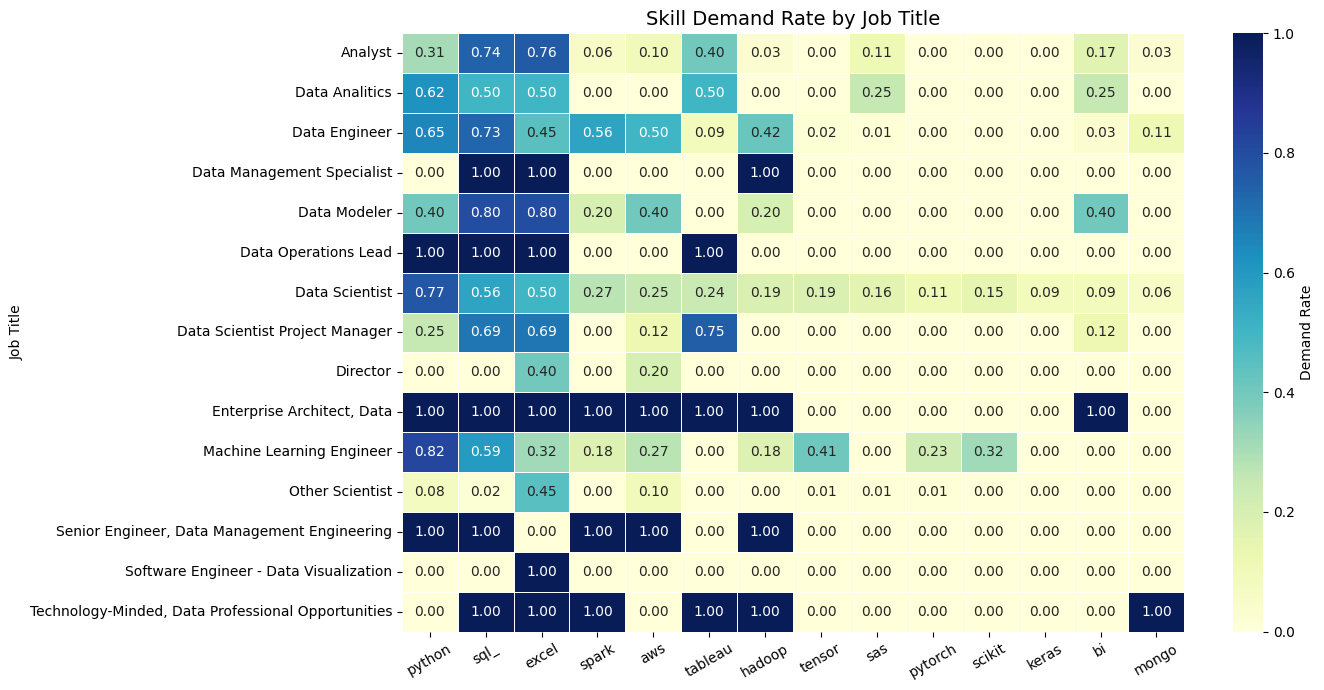

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Skills Required by Companies for Each Job Title
skills = ['python', 'sql_', 'excel', 'spark', 'aws', 'tableau', 'hadoop',
          'tensor', 'sas', 'pytorch', 'scikit', 'keras', 'bi', 'mongo']

skills_analysis = df.groupby('job_title_sim')[skills].mean().round(2)
print(skills_analysis)

plt.figure(figsize=(14, 7))
sns.heatmap(skills_analysis, annot=True, fmt='.2f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Demand Rate'})
plt.title('Skill Demand Rate by Job Title', fontsize=14)
plt.ylabel('Job Title')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

degree
P          115981.31
M          105634.92
Unknown     94703.66
Name: avg_salary, dtype: float64


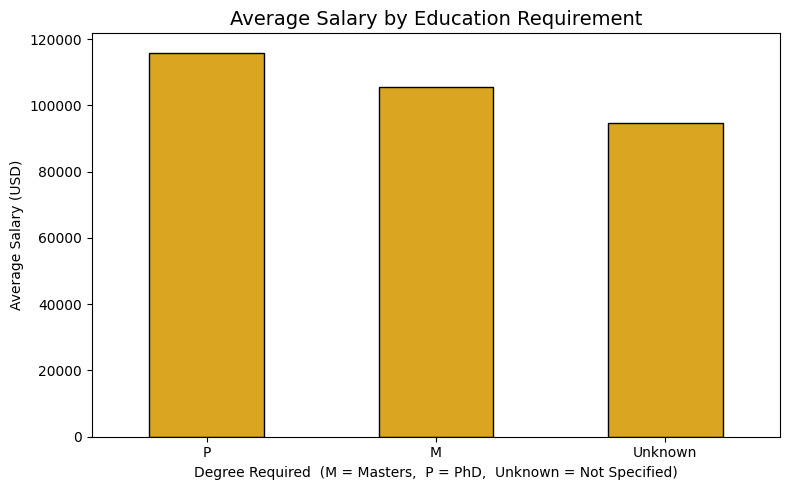

In [ ]:
# Task 9 — Relation Between Average Salary and Education
salary_edu = df.groupby('degree')['avg_salary'].mean().sort_values(ascending=False).round(2)
print(salary_edu)

plt.figure(figsize=(8, 5))
salary_edu.plot(kind='bar', color='goldenrod', edgecolor='black')
plt.title('Average Salary by Education Requirement', fontsize=14)
plt.xlabel('Degree Required  (M = Masters,  P = PhD,  Unknown = Not Specified)')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

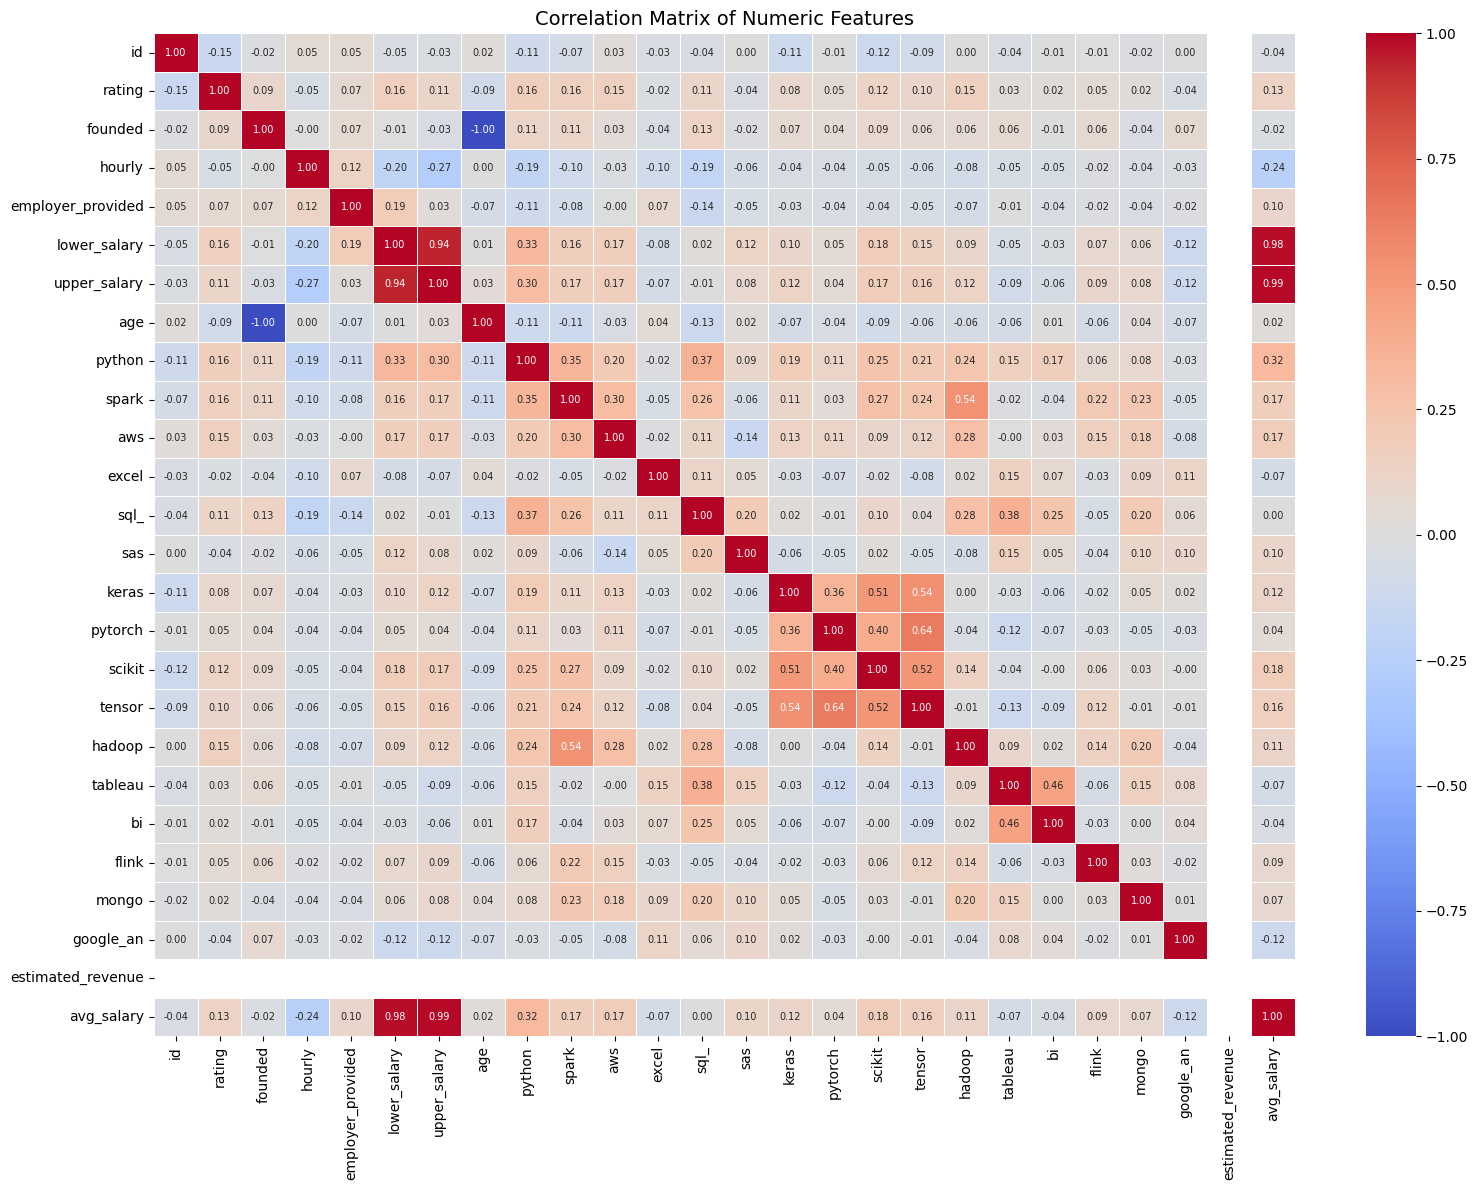

In [ ]:
# Analyze All Features: and derive multiple insights (Correlation Matrix)
corr = df.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Matrix of Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

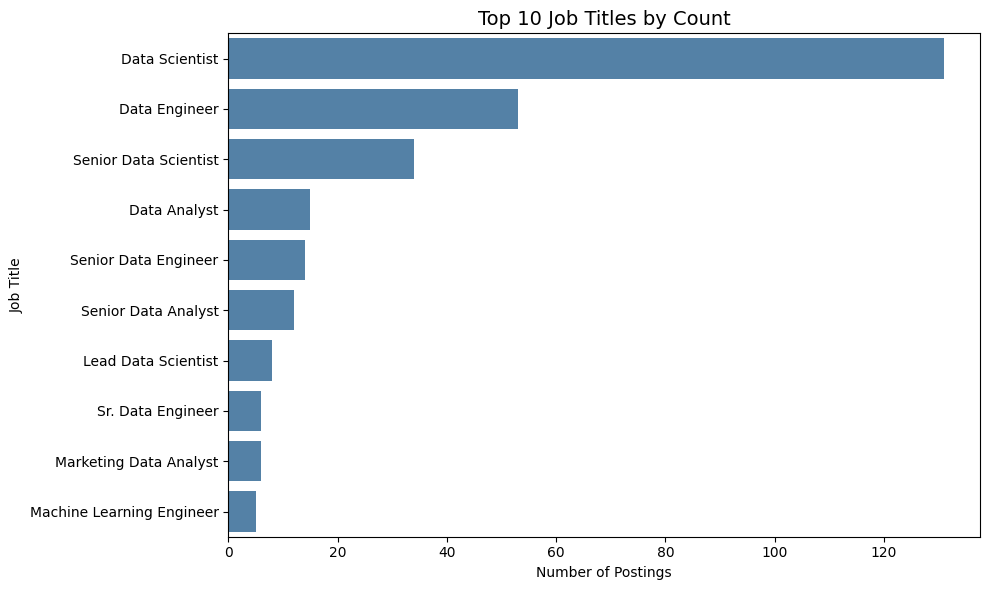

In [ ]:
# Visualization 1 — Top 10 Job Titles
top_jobs = df['job_title'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_jobs.values, y=top_jobs.index, color='steelblue')
plt.title('Top 10 Job Titles by Count', fontsize=14)
plt.xlabel('Number of Postings')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

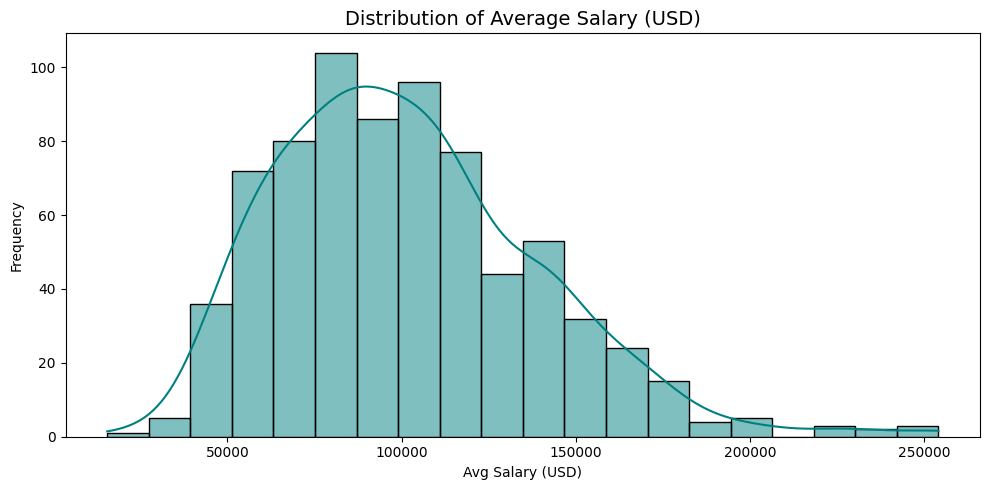

In [ ]:
### Visualization 2 — Salary Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['avg_salary'], bins=20, kde=True, color='teal')
plt.title('Distribution of Average Salary (USD)', fontsize=14)
plt.xlabel('Avg Salary (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

python     52.8
excel      52.3
sql_       51.2
aws        23.7
spark      22.5
tableau    19.9
hadoop     16.7
tensor      9.7
sas         8.9
bi          7.5
scikit      7.3
pytorch     5.3
mongo       5.0
keras       3.9
dtype: float64


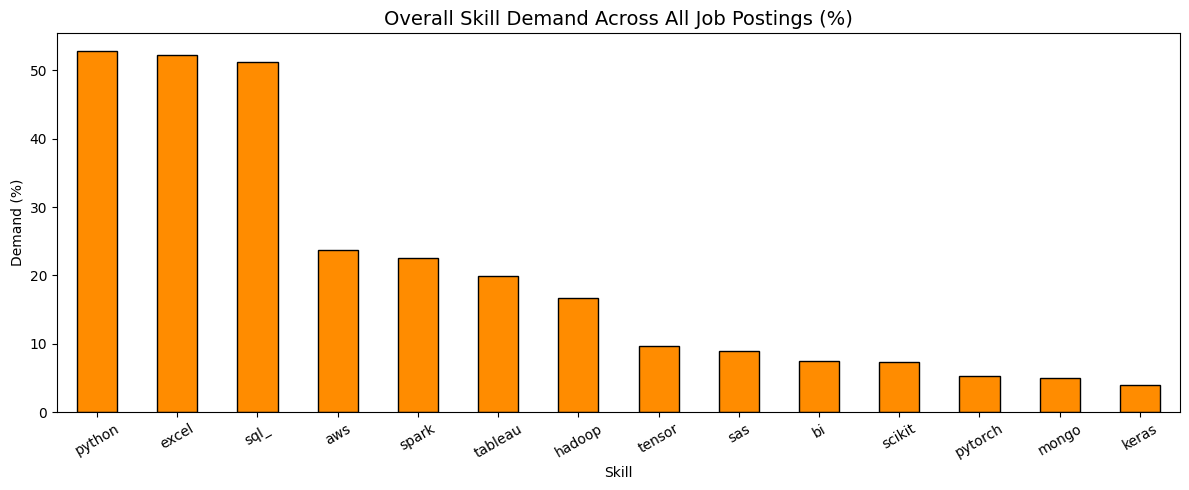

In [ ]:
# Visualization 3 — Overall Skill Demand (All Job Titles)
overall_skills = df[skills].mean().sort_values(ascending=False).round(3) * 100
print(overall_skills)

plt.figure(figsize=(12, 5))
overall_skills.plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Overall Skill Demand Across All Job Postings (%)', fontsize=14)
plt.xlabel('Skill')
plt.ylabel('Demand (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### Step 6: Save the Cleaned DataFrame


In [ ]:
df.to_csv('job_market_cleaned.csv', index=False)
print('Cleaned dataset saved as job_market_cleaned.csv')

from google.colab import files
files.download('job_market_cleaned.csv')

Cleaned dataset saved as job_market_cleaned.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# df.to_csv('job_market_raw.csv', index=False)
# print('Raw dataset saved as job_market_raw.csv')

# from google.colab import files
# files.download('job_market_raw.csv')